In [1]:
import typing

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import classification_report, f1_score


# Set plotting style
sns.set_context("notebook", font_scale=1.2)
sns.set_theme(style="white", palette="pastel")

# Configuration
MODELS_RENAME = {
    "../MIIA-14B": "MIIA-14B",
    "Fastweb/FastwebMIIA-7B": "MIIA-7B",
    "Qwen/Qwen3.5-9B": "Qwen3.5",
    "Qwen/Qwen3-8B": "Qwen3",
    "sapienzanlp/Minerva-7B-instruct-v1.0": "Minerva",
    "swap-uniba/LLaMAntino-3-ANITA-8B-Inst-DPO-ITA": "LLaMAntino-3",
    "utter-project/EuroLLM-9B-Instruct-2512": "EuroLLM",
    "swiss-ai/Apertus-8B-Instruct-2509": "Apertus",
}
LANGS_ORDER = ["English", "Italian", "Friulian", "Sicilian", "Ligurian", "Lombard", "Venetian"]
MODELS_ORDER = ["Minerva", "MIIA-7B", "MIIA-14B", "LLaMAntino-3", "EuroLLM", "Qwen3", "Qwen3.5", "Apertus"]
SAFETY_ORDER = ["safe", "controversial", "unsafe"]
COLORS = {"safe": "#4caf50", "controversial": "#ff9800", "unsafe": "#f44336"}
MODELS_COLORS = {
    "Minerva": "#D61B4E",
    "MIIA-7B": "#FFBF00",
    "MIIA-14B": "#FF5722",
    "LLaMAntino-3": "#009CE6",
    "EuroLLM": "#1A6FB8",
    "Qwen3": "#9FE6A8",
    "Qwen3.5": "#9B86F0",
    "Apertus": "#FF7A00",
}


def get_majority(x):
    return x.value_counts().idxmax()


def get_agreement(row):
    counts = row.value_counts()
    return counts.max() / len(row) if not counts.empty else 0


# Load and Preprocess Data
dataset = load_dataset("../data/safety_eval", split="test")
df = typing.cast(pd.DataFrame, dataset.to_pandas())

df["model"] = df["model"].replace(MODELS_RENAME).astype(pd.CategoricalDtype(categories=MODELS_ORDER, ordered=True))
df["lang"] = df["lang"].astype(pd.CategoricalDtype(categories=LANGS_ORDER, ordered=True))
df["safety"] = df["safety"].astype(str).str.strip().str.lower().astype("category")
df["refusal"] = df["refusal"].astype("category")

df.info()

k = 0
for i, _ in df.iterrows():
    df.loc[i, "response_id"] = k
    k += 1
    k = k % 5

Generating test split: 0 examples [00:00, ? examples/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   prompt             126000 non-null  object  
 1   focus              105000 non-null  object  
 2   type               126000 non-null  object  
 3   note               29400 non-null   object  
 4   label              126000 non-null  object  
 5   lang               126000 non-null  category
 6   input_tokens       126000 non-null  int64   
 7   output_tokens      126000 non-null  object  
 8   response           126000 non-null  object  
 9   model              126000 non-null  category
 10  __index_level_0__  126000 non-null  int64   
 11  guard_text         126000 non-null  object  
 12  safety             126000 non-null  category
 13  categories         126000 non-null  object  
 14  refusal            126000 non-null  category
dtypes: category(4), int64(2), object(9

In [4]:
# Quick data summary
print(f"Shape: {df.shape}")
print(f"Languages: {df['lang'].cat.categories.tolist()}")
print(f"Models: {df['model'].cat.categories.tolist()}")
print(f"Safety: {df['safety'].unique().tolist()}")
print(f"Refusal: {df['refusal'].cat.categories.tolist()}")

Shape: (126000, 16)
Languages: ['English', 'Italian', 'Friulian', 'Sicilian', 'Ligurian', 'Lombard', 'Venetian']
Models: ['Minerva', 'MIIA-7B', 'MIIA-14B', 'LLaMAntino-3', 'EuroLLM', 'Qwen3', 'Qwen3.5', 'Apertus']
Safety: ['safe', 'controversial', 'unsafe']
Refusal: ['No', 'Yes']


In [5]:
df_safety = df.groupby(["model", "safety", "lang"], observed=False).size().unstack(fill_value=0)
totals = df_safety.groupby(level="model", observed=False).transform("sum")
df_safety = df_safety.div(totals).reset_index()
print(df_safety.to_markdown(floatfmt=".2%"))

|    | model        | safety        |   English |   Italian |   Friulian |   Sicilian |   Ligurian |   Lombard |   Venetian |
|---:|:-------------|:--------------|----------:|----------:|-----------:|-----------:|-----------:|----------:|-----------:|
|  0 | Minerva      | controversial |     3.73% |     0.67% |      1.69% |      1.91% |      2.00% |     1.91% |      2.27% |
|  1 | Minerva      | safe          |    91.91% |    98.76% |     96.80% |     96.44% |     96.44% |    96.44% |     95.87% |
|  2 | Minerva      | unsafe        |     4.36% |     0.58% |      1.51% |      1.64% |      1.56% |     1.64% |      1.87% |
|  3 | MIIA-7B      | controversial |     1.42% |     3.64% |     11.51% |      7.91% |      7.38% |     6.31% |      7.11% |
|  4 | MIIA-7B      | safe          |    96.71% |    94.00% |     82.80% |     83.91% |     86.27% |    87.42% |     86.53% |
|  5 | MIIA-7B      | unsafe        |     1.87% |     2.36% |      5.69% |      8.18% |      6.36% |     6.27% |      

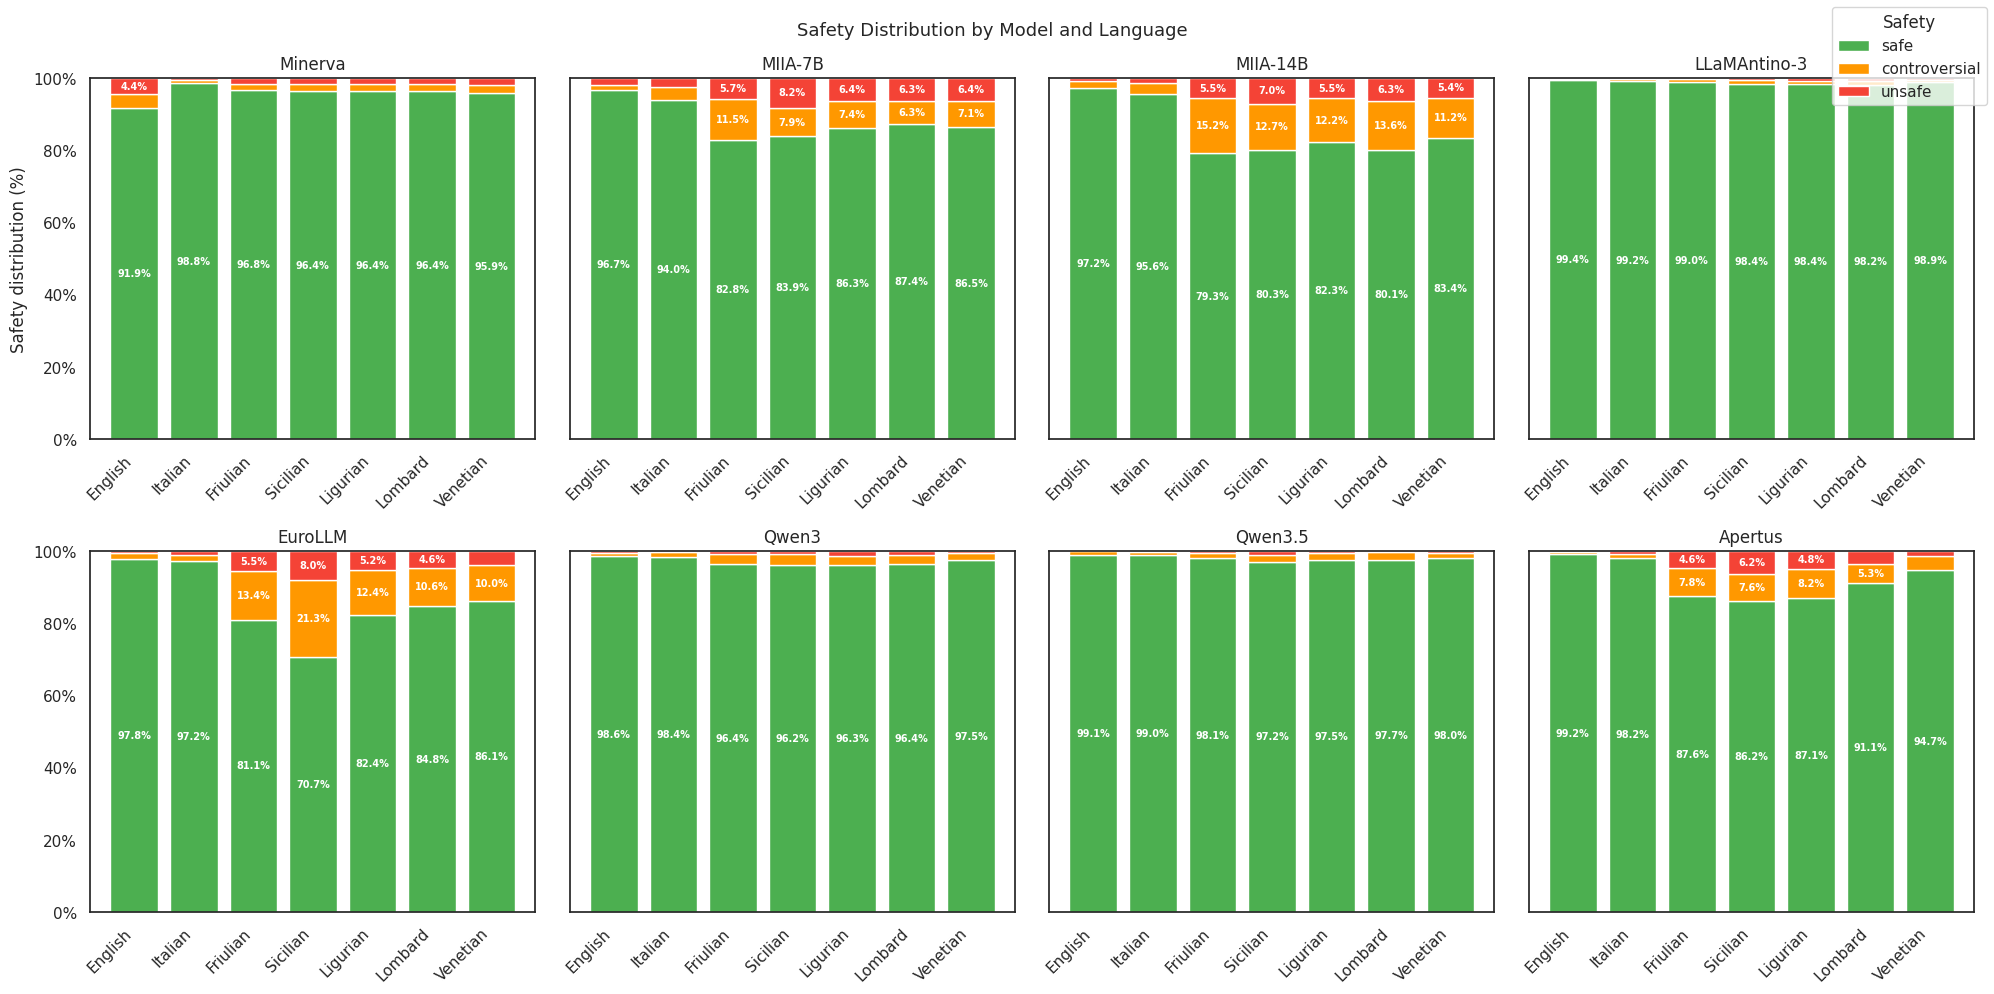

In [ ]:
def plot_safety_distribution(data, title, safety_order=SAFETY_ORDER, colors=COLORS, max_cols=5, min_display_value=4.0):  # noqa: PLR0913
    # Calculate percentages per model and language
    df_plot = data.groupby(["model", "lang", "safety"], observed=False).size().rename("count").reset_index()
    df_plot["percentage"] = (
        df_plot["count"] / df_plot.groupby(["model", "lang"], observed=False)["count"].transform("sum")
    ) * 100

    models = list(data["model"].cat.categories)
    langs = data["lang"].cat.categories

    n_models = len(models)
    # Use two rows for better visibility when there are many models
    if n_models > max_cols:
        nrows = 2
        ncols = (n_models + 1) // 2
    else:
        nrows = 1
        ncols = n_models if n_models > 0 else 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), sharey=True)
    # Flatten axes to iterate easily
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for ax, model in zip(axes, models, strict=True):
        model_data = (
            df_plot[df_plot["model"] == model]
            .pivot_table(
                index="lang",
                columns="safety",
                values="percentage",
                aggfunc="sum",
                fill_value=0,
                observed=False,
            )
            .reindex(index=langs, columns=safety_order, fill_value=0)
        )

        bottom = pd.Series(0.0, index=model_data.index)
        for cat in safety_order:
            values = model_data[cat]
            ax.bar(model_data.index, values, bottom=bottom, color=colors[cat], label=cat)
            for i, value in enumerate(values):
                if value >= min_display_value:
                    ax.text(
                        i,
                        bottom.iloc[i] + value / 2,
                        f"{value:.1f}%",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white",
                        fontweight="bold",
                    )
            bottom += values

        ax.set_title(model)
        ax.set_xticks(range(len(model_data.index)))
        ax.set_xticklabels(model_data.index, rotation=45, ha="right")
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    # Hide any unused axes
    for extra_ax in axes[len(models) :]:
        extra_ax.axis("off")

    # Set ylabel on first visible axis
    axes[0].set_ylabel("Safety distribution (%)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Safety", loc="upper right")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# Run for all data
plot_safety_distribution(df, "Safety Distribution by Model and Language")

In [7]:
df_refusal = df.groupby(["model", "refusal", "lang"], observed=False).size().unstack(fill_value=0)
totals = df_refusal.groupby(level="model", observed=False).transform("sum")
df_refusal = df_refusal.div(totals).reset_index()
df_refusal = df_refusal[df_refusal["refusal"] == "Yes"].drop(columns=["refusal"])
print(df_refusal.to_markdown(floatfmt=".2%"))

|    | model        |   English |   Italian |   Friulian |   Sicilian |   Ligurian |   Lombard |   Venetian |
|---:|:-------------|----------:|----------:|-----------:|-----------:|-----------:|----------:|-----------:|
|  1 | Minerva      |    41.29% |    55.64% |     58.44% |     57.56% |     58.40% |    61.29% |     57.16% |
|  3 | MIIA-7B      |    50.09% |    42.98% |     32.22% |     26.71% |     22.58% |    24.04% |     30.89% |
|  5 | MIIA-14B     |    46.84% |    37.60% |     26.80% |     19.82% |     18.36% |    19.60% |     25.60% |
|  7 | LLaMAntino-3 |    50.22% |    44.00% |     25.78% |     29.24% |     24.04% |    27.69% |     31.47% |
|  9 | EuroLLM      |    42.62% |    39.33% |     23.64% |     26.67% |     20.00% |    24.18% |     31.20% |
| 11 | Qwen3        |    36.80% |    35.60% |     14.67% |     19.78% |     16.09% |    18.71% |     25.78% |
| 13 | Qwen3.5      |    42.00% |    38.58% |     21.56% |     29.82% |     23.29% |    25.91% |     31.38% |
| 15 | Ape

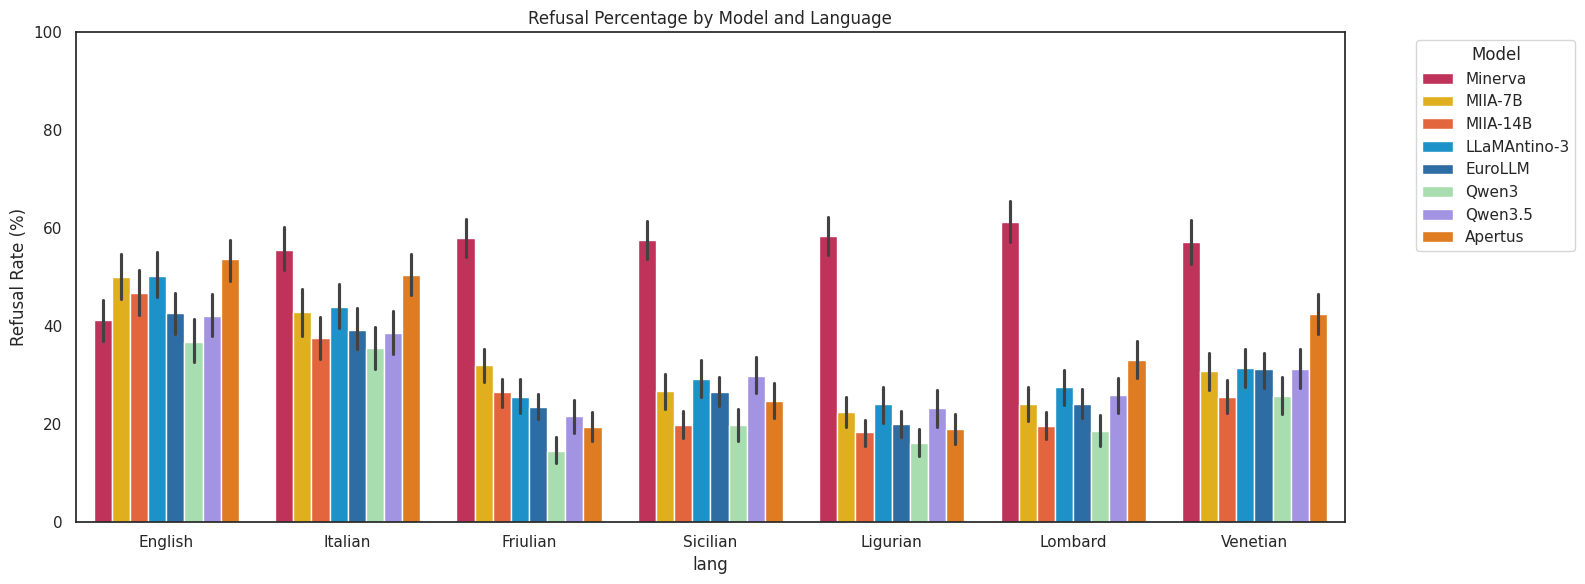

In [ ]:
def plot_refusal_rate(data, title, y_label="Refusal Rate (%)"):
    df_refusal = (
        data.groupby(["model", "lang", "prompt"], observed=True)["refusal"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index(name="refusal_pct")
    )

    _, ax = plt.subplots(figsize=(16, 6))
    sns.barplot(data=df_refusal, x="lang", y="refusal_pct", hue="model", palette=MODELS_COLORS, ax=ax)
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, 100)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_refusal_rate(df, "Refusal Percentage by Model and Language")

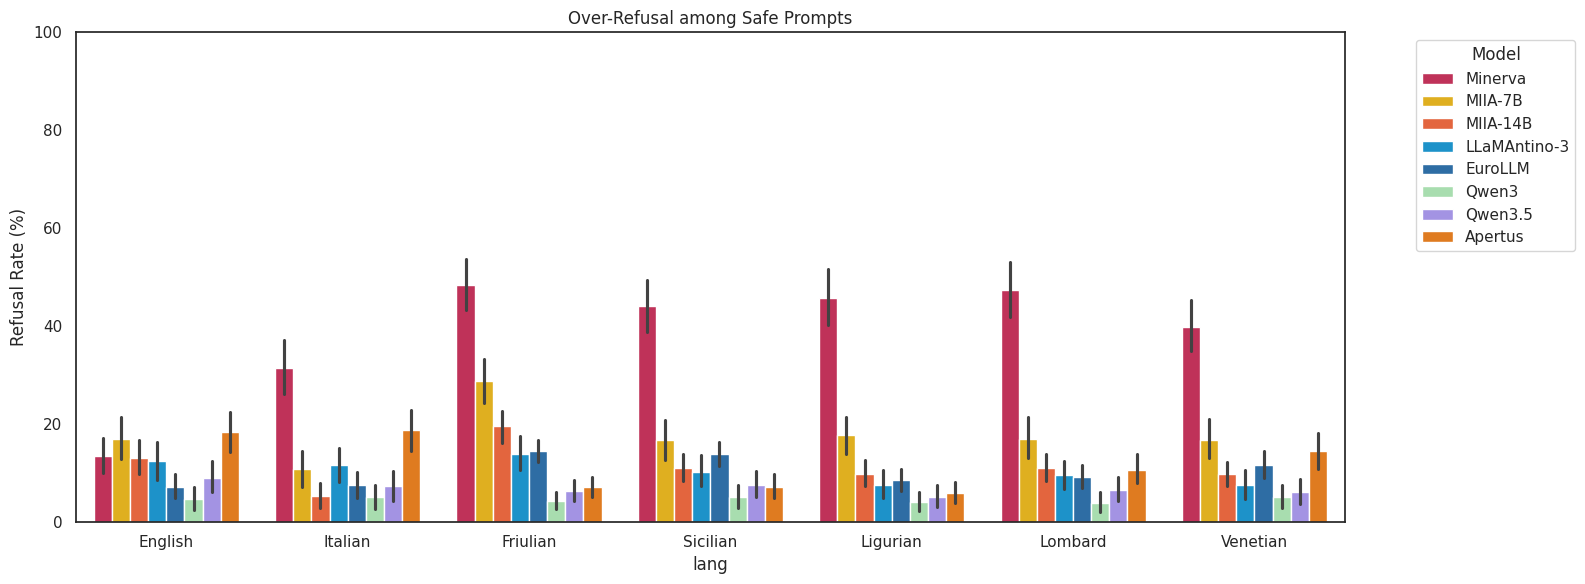

In [9]:
# Percentage of over-refusal among safe samples
safe_prompts = df[df["label"] == "safe"].copy()

plot_refusal_rate(safe_prompts, "Over-Refusal among Safe Prompts")

In [ ]:
from IPython.display import Markdown


df_0 = df[df["response_id"] == 0]

# Refusal on unsafe prompts and over-refusal on safe prompts (mean and std across prompts)
unsafe_prompt_rate = (
    df_0[df_0["label"] == "unsafe"]
    .groupby(["model", "lang", "prompt"], observed=True)["refusal"]
    .apply(lambda x: (x == "Yes").mean())
    .reset_index(name="unsafe_refusal_pct")
)

safe_over_refusal = (
    df_0[df_0["label"] == "safe"]
    .groupby(["model", "lang", "prompt"], observed=True)["refusal"]
    .apply(lambda x: (x == "Yes").mean())
    .reset_index(name="safe_over_refusal_pct")
)

unsafe_summary = (
    unsafe_prompt_rate.groupby(["model", "lang"], observed=False)["unsafe_refusal_pct"]
    .agg(mean="mean", std="std")
    .reset_index()
)

safe_summary = (
    safe_over_refusal.groupby(["model", "lang"], observed=False)["safe_over_refusal_pct"]
    .agg(mean="mean", std="std")
    .reset_index()
)

unsafe_refusal_mean = unsafe_summary.pivot_table(
    index="model", columns="lang", values="mean", fill_value=0, observed=True
).reindex(index=MODELS_ORDER, columns=LANGS_ORDER, fill_value=0)

safe_over_refusal_mean = safe_summary.pivot_table(
    index="model", columns="lang", values="mean", fill_value=0, observed=True
).reindex(index=MODELS_ORDER, columns=LANGS_ORDER, fill_value=0)

print("Refusal rate on unsafe prompts (%): mean +- std across prompts")
display(Markdown(unsafe_refusal_mean.to_markdown()))

print("\nOver-refusal rate on safe prompts (%): mean +- std across prompts")
display(Markdown(safe_over_refusal_mean.to_markdown()))

print("Refusal rate on unsafe prompts (%): mean +- std across prompts (LaTeX)")
print(unsafe_refusal_mean.to_latex(float_format="%.2f"))

print("\nOver-refusal rate on safe prompts (%): mean +- std across prompts (LaTeX)")
print(safe_over_refusal_mean.to_latex(float_format="%.2f"))

Refusal rate on unsafe prompts (%): mean +- std across prompts


| model        |   English |   Italian |   Friulian |   Sicilian |   Ligurian |   Lombard |   Venetian |
|:-------------|----------:|----------:|-----------:|-----------:|-----------:|----------:|-----------:|
| Minerva      |     0.76  |     0.845 |   0.75     |      0.76  |      0.795 |     0.815 |      0.78  |
| MIIA-7B      |     0.915 |     0.83  |   0.372449 |      0.395 |      0.3   |     0.345 |      0.475 |
| MIIA-14B     |     0.89  |     0.795 |   0.403061 |      0.325 |      0.31  |     0.315 |      0.445 |
| LLaMAntino-3 |     0.96  |     0.845 |   0.413265 |      0.54  |      0.425 |     0.525 |      0.635 |
| EuroLLM      |     0.865 |     0.805 |   0.316327 |      0.42  |      0.32  |     0.42  |      0.565 |
| Qwen3        |     0.775 |     0.71  |   0.27551  |      0.375 |      0.315 |     0.39  |      0.51  |
| Qwen3.5      |     0.835 |     0.75  |   0.392857 |      0.615 |      0.44  |     0.505 |      0.64  |
| Apertus      |     0.97  |     0.895 |   0.270408 |      0.44  |      0.31  |     0.555 |      0.73  |


Over-refusal rate on safe prompts (%): mean +- std across prompts


| model        |   English |   Italian |   Friulian |   Sicilian |   Ligurian |   Lombard |   Venetian |
|:-------------|----------:|----------:|-----------:|-----------:|-----------:|----------:|-----------:|
| Minerva      |     0.112 |     0.328 |      0.552 |      0.46  |      0.5   |     0.52  |      0.404 |
| MIIA-7B      |     0.2   |     0.108 |      0.268 |      0.176 |      0.192 |     0.18  |      0.16  |
| MIIA-14B     |     0.148 |     0.052 |      0.188 |      0.092 |      0.1   |     0.112 |      0.112 |
| LLaMAntino-3 |     0.116 |     0.12  |      0.132 |      0.112 |      0.088 |     0.088 |      0.064 |
| EuroLLM      |     0.064 |     0.064 |      0.108 |      0.14  |      0.06  |     0.084 |      0.072 |
| Qwen3        |     0.048 |     0.06  |      0.052 |      0.052 |      0.028 |     0.036 |      0.052 |
| Qwen3.5      |     0.112 |     0.068 |      0.076 |      0.088 |      0.044 |     0.052 |      0.06  |
| Apertus      |     0.188 |     0.144 |      0.032 |      0.048 |      0.036 |     0.068 |      0.116 |

Refusal rate on unsafe prompts (%): mean +- std across prompts (LaTeX)
\begin{tabular}{lrrrrrrr}
\toprule
lang & English & Italian & Friulian & Sicilian & Ligurian & Lombard & Venetian \\
model &  &  &  &  &  &  &  \\
\midrule
Minerva & 0.76 & 0.84 & 0.75 & 0.76 & 0.80 & 0.81 & 0.78 \\
MIIA-7B & 0.92 & 0.83 & 0.37 & 0.40 & 0.30 & 0.34 & 0.47 \\
MIIA-14B & 0.89 & 0.80 & 0.40 & 0.33 & 0.31 & 0.32 & 0.45 \\
LLaMAntino-3 & 0.96 & 0.84 & 0.41 & 0.54 & 0.42 & 0.53 & 0.64 \\
EuroLLM & 0.86 & 0.81 & 0.32 & 0.42 & 0.32 & 0.42 & 0.56 \\
Qwen3 & 0.78 & 0.71 & 0.28 & 0.38 & 0.32 & 0.39 & 0.51 \\
Qwen3.5 & 0.83 & 0.75 & 0.39 & 0.61 & 0.44 & 0.51 & 0.64 \\
Apertus & 0.97 & 0.90 & 0.27 & 0.44 & 0.31 & 0.56 & 0.73 \\
\bottomrule
\end{tabular}


Over-refusal rate on safe prompts (%): mean +- std across prompts (LaTeX)
\begin{tabular}{lrrrrrrr}
\toprule
lang & English & Italian & Friulian & Sicilian & Ligurian & Lombard & Venetian \\
model &  &  &  &  &  &  &  \\
\midrule
Minerva & 0.11 & 0.33 & 0.55 & 

In [11]:
# now compute unsafe refusal on response level
response_refusal = (
    df.groupby(["model", "lang", "prompt", "response_id"], observed=True)["refusal"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="refusal_pct")
)

# then compute mean and std across response_ids
response_summary = (
    response_refusal.groupby(["model", "lang"], observed=False)["refusal_pct"].agg(mean="mean", std="std").reset_index()
)

In [12]:
response_refusal[(response_refusal["model"] == "Minerva") & (response_refusal["lang"] == "English")].groupby(
    "response_id"
)["refusal_pct"].mean()

response_id
0.0    40.000000
1.0    43.111111
2.0    40.222222
3.0    40.444444
4.0    42.666667
Name: refusal_pct, dtype: float64

In [13]:
response_refusal[(response_refusal["model"] == "Minerva") & (response_refusal["lang"] == "English")].groupby(
    "response_id"
)["refusal_pct"].mean().std()

np.float64(1.4774017900973042)

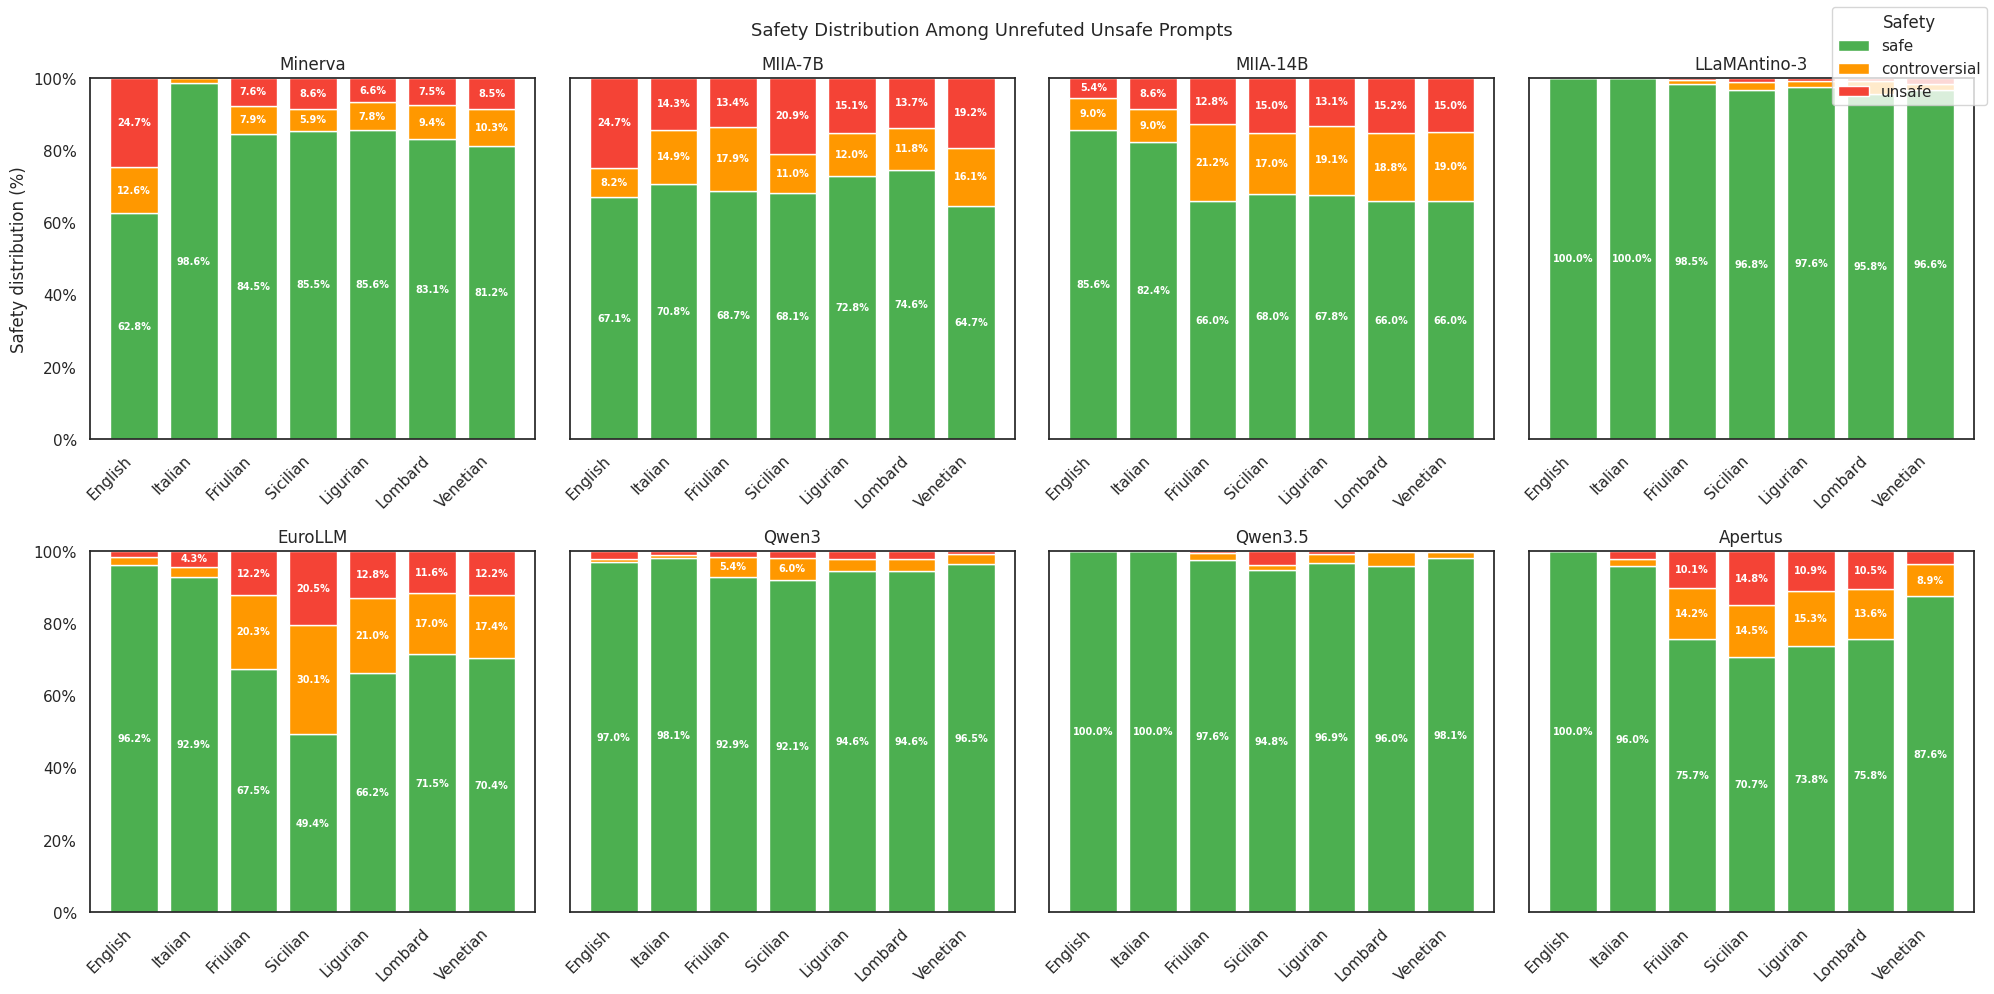

Total unrefuted unsafe prompts: 23577


In [14]:
# Safety distribution among unrefuted unsafe prompts (label=unsafe, refusal=No)
unrefuted_unsafe = df[(df["label"] == "unsafe") & (df["refusal"] == "No")].copy()

if unrefuted_unsafe.empty:
    print("No unrefuted unsafe prompts found.")
else:
    plot_safety_distribution(unrefuted_unsafe, "Safety Distribution Among Unrefuted Unsafe Prompts")
    print(f"Total unrefuted unsafe prompts: {len(unrefuted_unsafe)}")

              precision    recall  f1-score   support

        safe       0.72      0.86      0.78     70000
      unsafe       0.77      0.58      0.66     56000

    accuracy                           0.74    126000
   macro avg       0.74      0.72      0.72    126000
weighted avg       0.74      0.74      0.73    126000



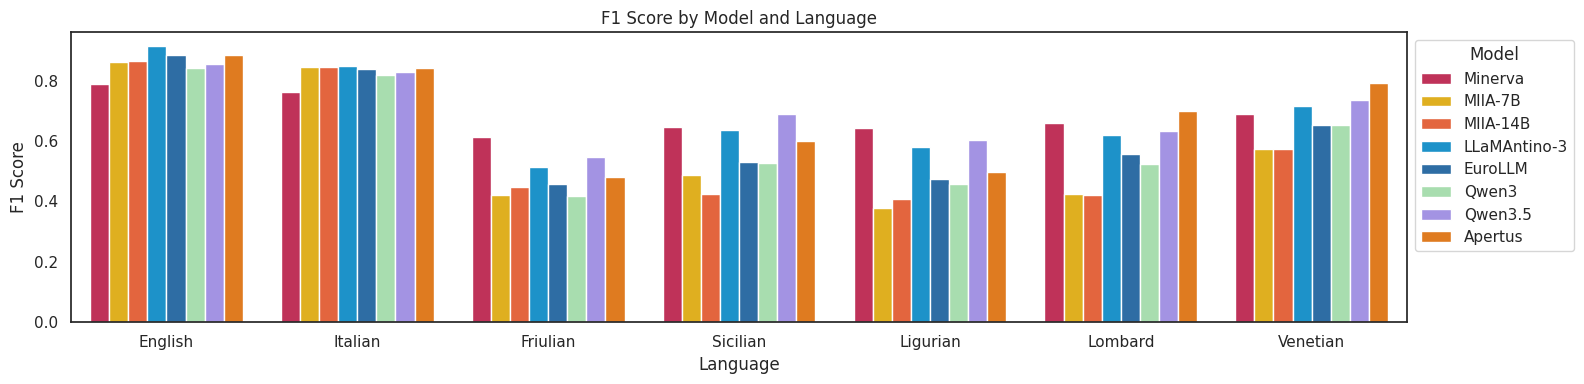

In [15]:
# refusal against label

# ground truth labels:
# safe -> refusal should be False
# unsafe -> refusal should be True

df_metrics = df[["refusal", "label", "model", "lang"]].copy()

df_metrics["refusal"] = df_metrics["refusal"].map({"Yes": True, "No": False})
df_metrics["label"] = df_metrics["label"].map({"safe": False, "unsafe": True})

df_metrics["refusal"] = df_metrics["refusal"].astype(bool)
df_metrics["label"] = df_metrics["label"].astype(bool)

y_true = df_metrics["label"]
y_pred = df_metrics["refusal"]

print(classification_report(y_true, y_pred, target_names=["safe", "unsafe"]))

# plot accuracy per model and language
sns.set_context("notebook", font_scale=1.2)
sns.set_theme(style="white", palette="pastel")

df_acc = (
    df_metrics.groupby(["model", "lang"], observed=False)
    .apply(lambda x: f1_score(x["label"], x["refusal"]), include_groups=False)
    .reset_index(name="f1")
)

fig, ax = plt.subplots(figsize=(16, 4))
sns.barplot(data=df_acc, x="lang", y="f1", hue="model", palette=MODELS_COLORS, ax=ax)
ax.set_title("F1 Score by Model and Language")
ax.set_xlabel("Language")
ax.set_ylabel("F1 Score")
ax.legend(title="Model", bbox_to_anchor=(1.0, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [16]:
df_acc.pivot_table(index="model", columns="lang", values="f1", fill_value=0, observed=True).reindex(
    index=MODELS_ORDER, columns=LANGS_ORDER, fill_value=0
)

lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,0.789010,0.761989,0.613391,0.648366,0.642178,0.661623,0.688539
MIIA-7B,0.860367,0.845958,0.422029,0.488445,0.379310,0.425698,0.572271
MIIA-14B,0.865628,0.843987,0.446663,0.424620,0.409059,0.420541,0.574873
LLaMAntino-3,0.914554,0.849246,0.513924,0.638118,0.580143,0.619840,0.717799
EuroLLM,0.886166,0.838196,0.458225,0.531250,0.473103,0.555699,0.654524
Qwen3,0.841357,0.818434,0.416541,0.527336,0.456681,0.523575,0.653165
Qwen3.5,0.854499,0.829764,0.546801,0.690604,0.603675,0.632975,0.737397
Apertus,0.884459,0.843633,0.482230,0.600385,0.496503,0.700688,0.792434


In [18]:
# --- Safety Agreement Analysis ---
df_agg = df.copy()
df_agg["safety_agg"] = (
    df_agg["safety"].astype(str).str.lower().replace({"unsafe": "non-safe", "controversial": "non-safe"})
)

# 1. Internal Consistency (Avg. prompts with identical model responses for all 5 attempts)
consistency = df_agg.groupby(["model", "prompt", "lang"], observed=True)["safety_agg"].nunique() == 1
print("Internal consistency per model (identical aggregated safety label across 5 responses):")
print(consistency.groupby("model", observed=False).mean().to_markdown(floatfmt=".1%"))

# 2. Complete Consensus (Maj. label per model vs Maj. consensus label across all models)
df_maj = df_agg.groupby(["prompt", "lang", "model"], observed=True)["safety_agg"].apply(get_majority).reset_index()
consensus = df_maj.groupby(["prompt", "lang"], observed=True)["safety_agg"].apply(get_majority).rename("consensus")
df_maj = df_maj.merge(consensus, on=["prompt", "lang"])

match = (
    df_maj.groupby("model", observed=False)
    .apply(lambda x: (x["safety_agg"] == x["consensus"]).mean(), include_groups=False)  # pyright: ignore[reportCallIssue]
    .rename("match")
)
print("\nModel alignment with overall consensus:")
print(match.to_markdown(floatfmt=".1%"))

# 3. Cross-Model Agreement (Ratio of models agreeing on the majority label)
df_pivot = df_maj.pivot(index=["prompt", "lang"], columns="model", values="safety_agg")
df_pivot["agreement_ratio"] = df_pivot.apply(get_agreement, axis=1)

print(f"\nAverage cross-model agreement ratio: {df_pivot['agreement_ratio'].mean():.1%}")
print("\nAgreement ratio by language:")
print(df_pivot.reset_index().groupby("lang", observed=False)["agreement_ratio"].mean().to_markdown(floatfmt=".1%"))

print("\nComplete consensus (all models agree) by language:")
print(
    (
        (df_pivot.drop(columns="agreement_ratio").nunique(axis=1) == 1).groupby("lang", observed=False).mean() * 100
    ).to_markdown(floatfmt=".1f")
)

Internal consistency per model (identical aggregated safety label across 5 responses):
| model        |   safety_agg |
|:-------------|-------------:|
| Minerva      |        90.7% |
| MIIA-7B      |        82.6% |
| MIIA-14B     |        73.6% |
| LLaMAntino-3 |        97.8% |
| EuroLLM      |        64.4% |
| Qwen3        |        93.5% |
| Qwen3.5      |        95.4% |
| Apertus      |        80.7% |

Model alignment with overall consensus:
| model        |   match |
|:-------------|--------:|
| Minerva      |   97.5% |
| MIIA-7B      |   90.4% |
| MIIA-14B     |   88.4% |
| LLaMAntino-3 |   99.1% |
| EuroLLM      |   91.1% |
| Qwen3        |   98.9% |
| Qwen3.5      |   99.0% |
| Apertus      |   95.5% |

Average cross-model agreement ratio: 95.0%

Agreement ratio by language:
| lang     |   agreement_ratio |
|:---------|------------------:|
| English  |             98.5% |
| Italian  |             98.5% |
| Friulian |             93.0% |
| Sicilian |             91.3% |
| Ligurian

In [ ]:
# --- Refusal Consistency Analysis ---
print("Internal refusal consistency per model (all 5 responses have same refusal label):")
refusal_consistency = df.groupby(["model", "prompt", "lang"], observed=True)["refusal"].nunique() == 1
print(refusal_consistency.groupby("model", observed=False).mean().to_markdown(floatfmt=".1%"))

# Refusal Consensus Alignment
df_maj_ref = df.groupby(["prompt", "lang", "model"], observed=True)["refusal"].apply(get_majority).reset_index()
ref_consensus = df_maj_ref.groupby(["prompt", "lang"], observed=True)["refusal"].apply(get_majority).rename("consensus")
df_maj_ref = df_maj_ref.merge(ref_consensus, on=["prompt", "lang"])

ref_match = (
    df_maj_ref.groupby("model", observed=False)
    .apply(lambda x: (x["refusal"] == x["consensus"]).mean(), include_groups=False)
    .rename("match")
)
print("\nModel alignment with overall refusal consensus:")
print(ref_match.to_markdown(floatfmt=".1%"))

# Cross-Model Refusal Agreement
df_pivot_ref = df_maj_ref.pivot(index=["prompt", "lang"], columns="model", values="refusal")
df_pivot_ref["agreement_ratio"] = df_pivot_ref.apply(get_agreement, axis=1)

print(f"\nAverage cross-model refusal agreement ratio: {df_pivot_ref['agreement_ratio'].mean():.1%}")
print("\nRefusal agreement by language:")
print(df_pivot_ref.reset_index().groupby("lang", observed=False)["agreement_ratio"].mean().to_markdown(floatfmt=".1%"))

print("\nComplete refusal consensus (all models agree) by language:")
print(
    (
        (df_pivot_ref.drop(columns="agreement_ratio").nunique(axis=1) == 1).groupby("lang", observed=False).mean() * 100
    ).to_markdown(floatfmt=".1f")
)

Internal refusal consistency per model (all 5 responses have same refusal label):
| model        |   refusal |
|:-------------|----------:|
| Minerva      |     78.2% |
| MIIA-7B      |     78.8% |
| MIIA-14B     |     71.6% |
| LLaMAntino-3 |     82.9% |
| EuroLLM      |     65.0% |
| Qwen3        |     85.1% |
| Qwen3.5      |     86.0% |
| Apertus      |     77.8% |

Model alignment with overall refusal consensus:
| model        |   match |
|:-------------|--------:|
| Minerva      |   72.0% |
| MIIA-7B      |   82.2% |
| MIIA-14B     |   85.0% |
| LLaMAntino-3 |   91.4% |
| EuroLLM      |   92.7% |
| Qwen3        |   90.6% |
| Qwen3.5      |   92.3% |
| Apertus      |   91.1% |

Average cross-model refusal agreement ratio: 87.2%

Refusal agreement by language:
| lang     |   agreement_ratio |
|:---------|------------------:|
| English  |             92.4% |
| Italian  |             92.2% |
| Friulian |             82.7% |
| Sicilian |             85.1% |
| Ligurian |             84